# Human vs Agent Score Variation

Compares the **inter-rater variability** of human graders (Hao, Zach, Chandan) to the **run-to-run variability** of agent scores across repeated runs on the same task.

- Human scores: `human_experiments/results.csv` — 3 graders × 29 teams
- Agent scores: `scalar_experiments/aggregated_results/aggregated_results.csv` — 20 runs × (dataset × distribution × perturbation) blocks

For each team, human variability = std of [Hao, Zach, Chandan].  
For each agent block, agent variability = std of the 20 run scores.

In [34]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

BASE_DIR = Path(".").resolve()
HUMAN_CSV = BASE_DIR / "results.csv"
AGENT_CSV = BASE_DIR / ".." / "scalar_experiments" / "aggregated_results" / "aggregated_results.csv"

In [35]:
# ── Load & clean human scores ──
human_df = pd.read_csv(HUMAN_CSV).dropna(subset=["Team Number"])
human_df["Team Number"] = human_df["Team Number"].astype(int)

HUMAN_RATERS = ["Hao", "Zach", "Chandan"]
human_df = human_df[["Team Number"] + HUMAN_RATERS].dropna()
human_df[HUMAN_RATERS] = human_df[HUMAN_RATERS].astype(float)

# Per-team: mean, std, and range across raters
human_df["mean_score"]  = human_df[HUMAN_RATERS].mean(axis=1)
human_df["std_score"]   = human_df[HUMAN_RATERS].std(axis=1, ddof=1)
human_df["range_score"] = human_df[HUMAN_RATERS].max(axis=1) - human_df[HUMAN_RATERS].min(axis=1)

print(f"Human data: {len(human_df)} teams")
human_df

Human data: 29 teams


,Team Number,Hao,Zach,Chandan,mean_score,std_score,range_score
0,1,58.0,60.0,80.0,66.000000,12.165525,22.0
1,2,55.0,55.0,55.0,55.000000,0.000000,0.0
2,3,92.0,80.0,80.0,84.000000,6.928203,12.0
3,4,14.0,25.0,20.0,19.666667,5.507571,11.0
4,5,78.0,70.0,85.0,77.666667,7.505553,15.0
5,6,0.0,15.0,35.0,16.666667,17.559423,35.0
6,7,75.0,75.0,70.0,73.333333,2.886751,5.0
7,8,83.0,60.0,70.0,71.000000,11.532563,23.0
8,9,95.0,85.0,80.0,86.666667,7.637626,15.0
9,10,93.0,90.0,80.0,87.666667,6.806859,13.0


In [36]:
# ── Load agent scores (soccer/alt only) ──
agent_df = pd.read_csv(AGENT_CSV, keep_default_na=False)
agent_df = agent_df[(agent_df["dataset"] == "soccer") & (agent_df["distribution"] == "alt")]

# Per perturbation block: std and range across 20 runs
agent_var = (
    agent_df.groupby(["dataset", "distribution", "perturbation"])["response"]
    .agg(n="count", mean="mean", std="std", range=lambda x: x.max() - x.min())
    .reset_index()
)

print(f"Agent data: {len(agent_df):,} rows → {len(agent_var)} perturbation blocks")
agent_var

Agent data: 100 rows → 5 perturbation blocks


,dataset,distribution,perturbation,n,mean,std,range
0,soccer,alt,add_features,20,59.85,12.106001,32
1,soccer,alt,anonymize,20,64.95,9.544770,32
2,soccer,alt,negative_leading_statement,20,63.15,11.604332,45
3,soccer,alt,positive_leading_statement,20,66.15,9.143735,38
4,soccer,alt,shuffle_names,20,67.15,3.407036,10


In [37]:
# ── Summary statistics ──
human_stds   = human_df["std_score"].dropna()
agent_stds   = agent_var["std"].dropna()
human_ranges = human_df["range_score"]
agent_ranges = agent_var["range"]

summary = pd.DataFrame({
    "source":       ["Human (3 raters)", "Agent (20 runs)"],
    "n":            [len(human_stds),    len(agent_stds)],
    "std_mean":     [human_stds.mean(),  agent_stds.mean()],
    "std_median":   [human_stds.median(),agent_stds.median()],
    "std_std":      [human_stds.std(),   agent_stds.std()],
    "range_mean":   [human_ranges.mean(),agent_ranges.mean()],
    "range_median": [human_ranges.median(),agent_ranges.median()],
})
summary

,source,n,std_mean,std_median,std_std,range_mean,range_median
0,Human (3 raters),29,10.541938,10.066446,5.499434,20.172414,20.0
1,Agent (20 runs),5,9.161175,9.544770,3.460440,31.400000,32.0


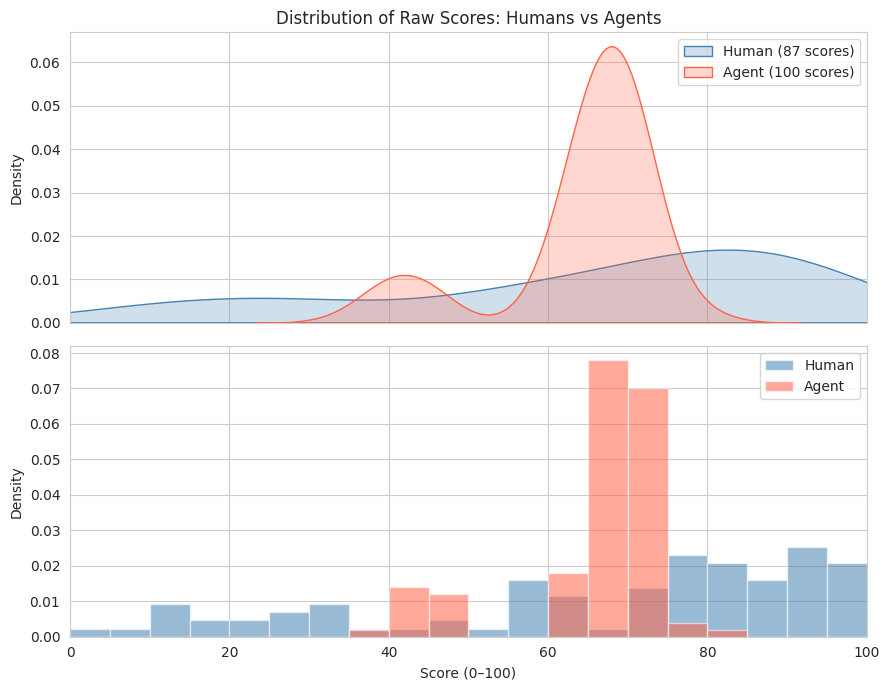

In [38]:
# ── KDE + histogram: raw score distributions (all human scores vs all agent scores) ──
all_human_scores = human_df[HUMAN_RATERS].values.flatten()
all_agent_scores = agent_df["response"].values

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax = axes[0]
sns.kdeplot(all_human_scores, ax=ax, label=f"Human ({len(all_human_scores)} scores)",
            color="steelblue", fill=True, alpha=0.25)
sns.kdeplot(all_agent_scores, ax=ax, label=f"Agent ({len(all_agent_scores)} scores)",
            color="tomato", fill=True, alpha=0.25)
ax.set_ylabel("Density")
ax.set_title("Distribution of Raw Scores: Humans vs Agents")
ax.legend(fontsize=10)

ax = axes[1]
bins = range(0, 105, 5)
ax.hist(all_human_scores, bins=bins, alpha=0.55, color="steelblue", label="Human", density=True)
ax.hist(all_agent_scores, bins=bins, alpha=0.55, color="tomato",    label="Agent",  density=True)
ax.set_xlabel("Score (0–100)")
ax.set_ylabel("Density")
ax.legend(fontsize=10)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

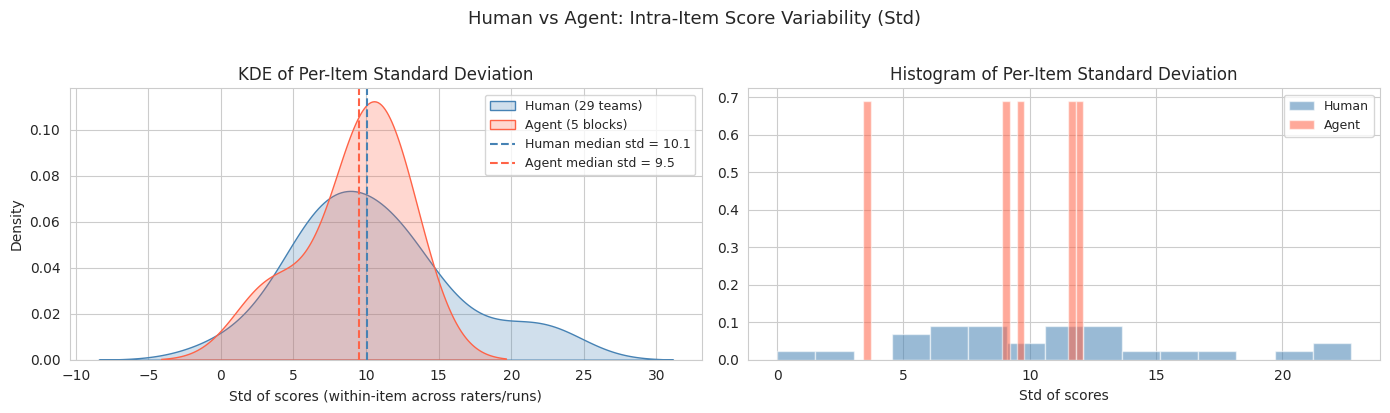

In [39]:
# ── KDE + histogram of per-item std ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.kdeplot(human_stds, ax=ax, label=f"Human ({len(human_stds)} teams)",
            color="steelblue", fill=True, alpha=0.25)
sns.kdeplot(agent_stds, ax=ax, label=f"Agent ({len(agent_stds)} blocks)",
            color="tomato", fill=True, alpha=0.25)
ax.axvline(human_stds.median(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Human median std = {human_stds.median():.1f}")
ax.axvline(agent_stds.median(), color="tomato", linestyle="--", linewidth=1.5,
           label=f"Agent median std = {agent_stds.median():.1f}")
ax.set_xlabel("Std of scores (within-item across raters/runs)")
ax.set_title("KDE of Per-Item Standard Deviation")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(human_stds, bins=15, alpha=0.55, color="steelblue", label="Human", density=True)
ax.hist(agent_stds, bins=30, alpha=0.55, color="tomato",    label="Agent",  density=True)
ax.set_xlabel("Std of scores")
ax.set_title("Histogram of Per-Item Standard Deviation")
ax.legend(fontsize=9)

plt.suptitle("Human vs Agent: Intra-Item Score Variability (Std)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

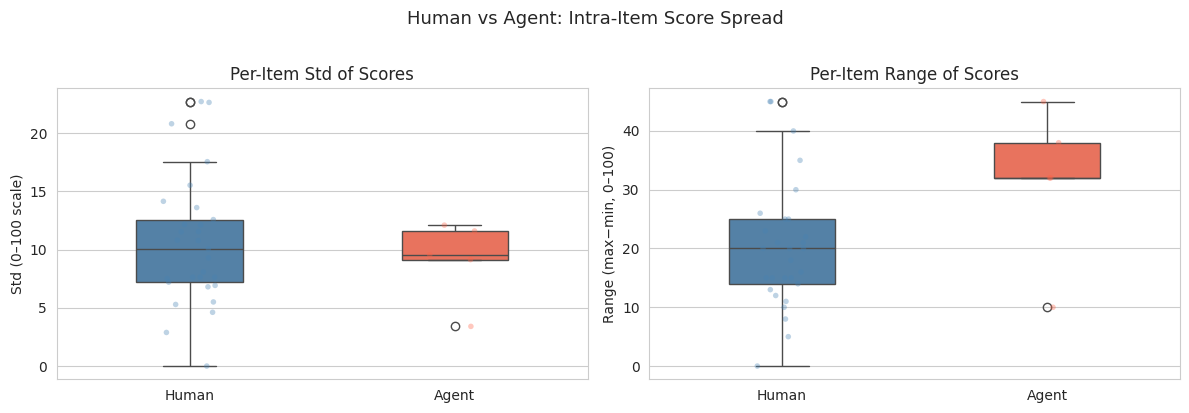

In [40]:
# ── Boxplot comparison of std and range ──
palette = {"Human": "steelblue", "Agent": "tomato"}

std_data = pd.DataFrame({
    "value":  list(human_stds)   + list(agent_stds),
    "source": ["Human"] * len(human_stds) + ["Agent"] * len(agent_stds),
})
range_data = pd.DataFrame({
    "value":  list(human_ranges) + list(agent_ranges),
    "source": ["Human"] * len(human_ranges) + ["Agent"] * len(agent_ranges),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, ylabel, title in [
    (axes[0], std_data,   "Std (0–100 scale)",        "Per-Item Std of Scores"),
    (axes[1], range_data, "Range (max−min, 0–100)",    "Per-Item Range of Scores"),
]:
    sns.boxplot(data=data, x="source", y="value", hue="source",
                palette=palette, ax=ax, width=0.4)
    sns.stripplot(data=data, x="source", y="value", hue="source",
                  palette=palette, ax=ax, alpha=0.35, size=4, jitter=True)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.suptitle("Human vs Agent: Intra-Item Score Spread", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

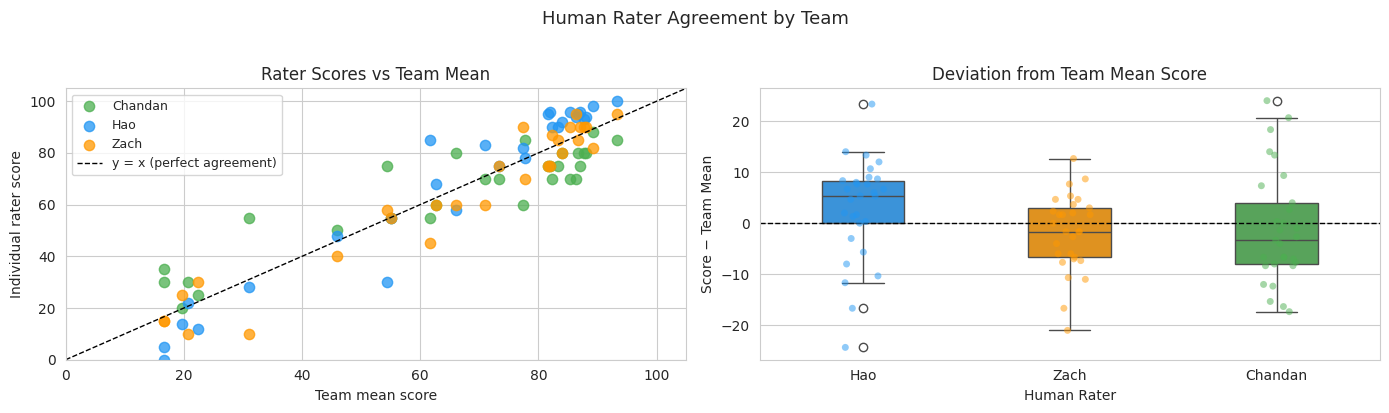


Deviation stats per rater (score − team mean):


,mean,median,std,mean_abs_dev
rater,,,,
Chandan,-1.068966,-3.333333,11.057347,8.931034
Hao,2.862069,5.333333,9.956460,8.356322
Zach,-1.793103,-1.666667,7.503128,5.908046


In [41]:
# ── Per-team: individual rater scores vs team mean ──
melted = human_df.melt(
    id_vars=["Team Number", "mean_score"],
    value_vars=HUMAN_RATERS,
    var_name="rater",
    value_name="score",
)
melted["deviation"] = melted["score"] - melted["mean_score"]

rater_palette = {"Hao": "#2196F3", "Zach": "#FF9800", "Chandan": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter: each rater's score vs team mean
ax = axes[0]
for rater, grp in melted.groupby("rater"):
    ax.scatter(grp["mean_score"], grp["score"], label=rater,
               color=rater_palette[rater], alpha=0.75, s=55)
ax.plot([0, 105], [0, 105], "k--", linewidth=1, label="y = x (perfect agreement)")
ax.set_xlim(0, 105); ax.set_ylim(0, 105)
ax.set_xlabel("Team mean score")
ax.set_ylabel("Individual rater score")
ax.set_title("Rater Scores vs Team Mean")
ax.legend(fontsize=9)

# Deviations from team mean, per rater
ax = axes[1]
sns.boxplot(data=melted, x="rater", y="deviation", hue="rater",
            palette=rater_palette, ax=ax, width=0.4, order=HUMAN_RATERS)
sns.stripplot(data=melted, x="rater", y="deviation", hue="rater",
              palette=rater_palette, ax=ax, alpha=0.5, size=5,
              jitter=True, order=HUMAN_RATERS)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Deviation from Team Mean Score")
ax.set_xlabel("Human Rater")
ax.set_ylabel("Score − Team Mean")

plt.suptitle("Human Rater Agreement by Team", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nDeviation stats per rater (score − team mean):")
melted.groupby("rater")["deviation"].agg(
    mean="mean", median="median", std="std",
    mean_abs_dev=lambda x: x.abs().mean()
)

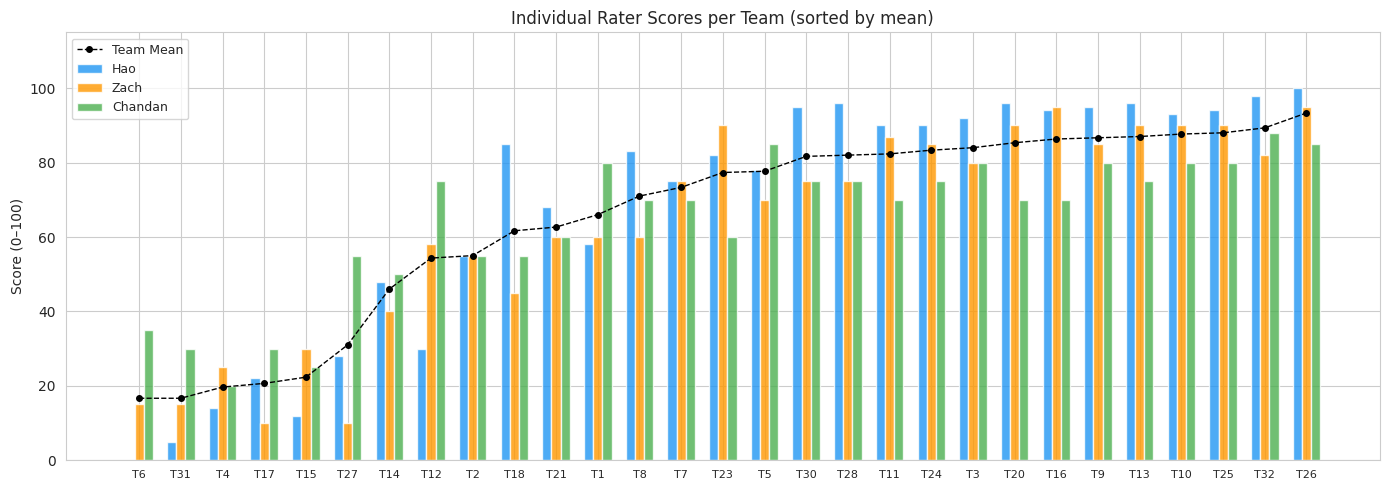

In [42]:
# ── Per-team bar chart: individual rater scores sorted by team mean ──
sorted_df = human_df.sort_values("mean_score").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(sorted_df))
width = 0.22

for i, (rater, color) in enumerate(rater_palette.items()):
    ax.bar(x + i * width, sorted_df[rater], width=width,
           label=rater, color=color, alpha=0.8)

ax.plot(x + width, sorted_df["mean_score"], "ko--",
        markersize=4, linewidth=1, label="Team Mean", zorder=5)

ax.set_xticks(x + width)
ax.set_xticklabels([f"T{t}" for t in sorted_df["Team Number"]], fontsize=8)
ax.set_ylabel("Score (0–100)")
ax.set_title("Individual Rater Scores per Team (sorted by mean)")
ax.legend(fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

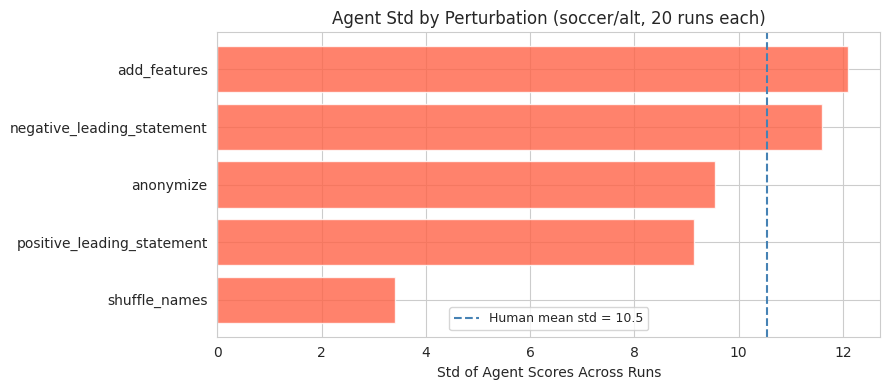


Agent std by perturbation:
              perturbation  n  mean       std  range
              add_features 20 59.85 12.106001     32
                 anonymize 20 64.95  9.544770     32
negative_leading_statement 20 63.15 11.604332     45
positive_leading_statement 20 66.15  9.143735     38
             shuffle_names 20 67.15  3.407036     10


In [43]:
# ── Agent variability by perturbation ──
fig, ax = plt.subplots(figsize=(9, 4))
agent_var_sorted = agent_var.sort_values("std")
ax.barh(agent_var_sorted["perturbation"], agent_var_sorted["std"],
        color="tomato", alpha=0.8)
ax.axvline(human_stds.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Human mean std = {human_stds.mean():.1f}")
ax.set_title("Agent Std by Perturbation (soccer/alt, 20 runs each)")
ax.set_xlabel("Std of Agent Scores Across Runs")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nAgent std by perturbation:")
print(agent_var[["perturbation", "n", "mean", "std", "range"]].to_string(index=False))

In [44]:
# ── Statistical comparison of variability distributions ──
t_stat, p_ttest = stats.ttest_ind(human_stds, agent_stds, equal_var=False)
u_stat, p_mwu   = stats.mannwhitneyu(human_stds, agent_stds, alternative="two-sided")
pooled_std      = np.sqrt((human_stds.std()**2 + agent_stds.std()**2) / 2)
cohens_d        = (human_stds.mean() - agent_stds.mean()) / pooled_std

print("Welch t-test (human std vs agent std):")
print(f"  t = {t_stat:.3f},  p = {p_ttest:.4f}")
print()
print("Mann-Whitney U (two-sided):")
print(f"  U = {u_stat:.1f},  p = {p_mwu:.4f}")
print()
print(f"Cohen's d = {cohens_d:.3f}  (human − agent, pooled std)")
print()
print("Final summary:")
summary

Welch t-test (human std vs agent std):
  t = 0.745,  p = 0.4777

Mann-Whitney U (two-sided):
  U = 78.0,  p = 0.8079

Cohen's d = 0.301  (human − agent, pooled std)

Final summary:


,source,n,std_mean,std_median,std_std,range_mean,range_median
0,Human (3 raters),29,10.541938,10.066446,5.499434,20.172414,20.0
1,Agent (20 runs),5,9.161175,9.544770,3.460440,31.400000,32.0
